# GameTheory-26 — Ensembles limites : Poincaré-Bendixson en dimension 2

Où peut bien finir une trajectoire d'apprentissage ? Posée dans le plan, la question a une réponse fermée : le théorème de **Poincaré-Bendixson** dit qu'un champ de vecteurs planaire ne peut faire qu'une de trois choses à une trajectoire — la faire converger vers un point, la faire tourner en boucle fermée, ou la faire coller à un cycle de coins. Pas de quatrième issue, et en particulier : **pas de chaos**.

Czechowski et Piliouras (2021) ont montré que ce théorème s'applique à la dynamique de replicateur dans les deux cadres planaires de la théorie des jeux : une population sur trois stratégies, et deux populations sur un jeu 2×2. Ce notebook **exécute** les trois issues — chacune fabriquée par un jeu canonique, intégrée par RK4, puis classée par un détecteur mécanique qui ne lit que la trajectoire.

Toute la mécanique vit dans le module compagnon [`limit_sets.py`](limit_sets.py) (deux cadres, intégrateur RK4, détecteur de régime), validé par [`tests/test_limit_sets.py`](tests/test_limit_sets.py) — 16 tests, dont la stabilité du verdict au pas d'intégration (dt vs dt/2) et à la condition initiale dans le bassin.

**Plan** : le théorème énoncé (section 1) ; les trois issues exécutées (section 2) ; le mur $w = l$ de la famille Pierre-Feuille-Ciseaux relié au vocabulaire chambres/murs du [GameTheory-3b](GameTheory-3b-Chambres-et-Murs.ipynb) (section 3) ; trois exercices (section 4) ; et pour finir, la raison pour laquelle tout ceci **tombe** dès qu'on quitte le plan.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import limit_sets as ls

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Contrôle sanitaire du module : RK4 conserve exactement les sommes des
# populations (invariant lineaire du champ) sur un court run Prisonnier.
A_pd, B_pd = ls.prisoner_dilemma_matrices()
t0s, tr0s = ls.integrate_rk4(lambda z: ls.replicator_2pop_rhs(A_pd, B_pd, z),
                             ls.make_state_2pop(0.6, 0.4), 2.0, 1e-3)
err_sommes = max(abs((tr0s[:, 0] + tr0s[:, 1]) - 1.0).max(),
                 abs((tr0s[:, 2] + tr0s[:, 3]) - 1.0).max())
print(f"Imports OK - conservation RK4 des sommes : erreur max {err_sommes:.1e}")

Imports OK - conservation RK4 des sommes : erreur max 1.6e-15


## 1. Le théorème : trois issues, pas une de plus

**Poincaré-Bendixson (forme utilisée).** Soit un champ de vecteurs continu sur une région fermée bornée du plan, avec un nombre fini de points fixes. L'ensemble $\omega$-limite d'une trajectoire qui reste confinée dans cette région est exactement l'un des trois objets suivants :

1. **un point fixe** — la trajectoire converge ;
2. **une orbite périodique** — la trajectoire parcourt une boucle fermée ;
3. **un cycle hétéroclinique** — une concaténation de trajectoires reliant des points fixes (typiquement des coins du domaine), parcourue sans jamais terminer.

Le théorème n'est pas prouvé ici : il est *exécuté*. Chaque issue est fabriquée par un jeu canonique, intégrée numériquement, et classée par le détecteur `detect_regime` — qui ne connaît pas le jeu, seulement la trajectoire. Ses trois signatures sont mécaniques : immobilité de la fenêtre terminale (point fixe), premier retour au point de départ (orbite périodique), collage à la frontière avec allongement des séjours (cycle hétéroclinique).

Pourquoi le théorème s'applique : la dynamique de replicateur $\dot{x}_i = x_i\,((Ax)_i - x^\top A x)$ vit dans le simplexe, et nos deux cadres sont planaires — le simplexe d'une population sur trois stratégies est un **triangle**, le produit des simplexes de deux populations sur un jeu 2×2 est un **carré**. Dans les deux cas, la dimension de l'espace d'états est 2.

In [2]:
# Deux contrôles du cadre : les centres sont bien des points fixes du champ.
A_mp, B_mp = ls.matching_pennies_matrices()
centre_mp = ls.make_state_2pop(0.5, 0.5)
champ_mp = ls.replicator_2pop_rhs(A_mp, B_mp, centre_mp)
bary = np.full(3, 1.0 / 3.0)
champ_rps = ls.replicator_1pop_rhs(ls.rps_matrix(1.5, 1.5), bary)
print("Matching Pennies, champ au centre du carre :", np.round(champ_mp, 12))
print("RPS mur w=l, champ au barycentre          :", np.round(champ_rps, 12))

Matching Pennies, champ au centre du carre : [0. 0. 0. 0.]
RPS mur w=l, champ au barycentre          : [-0.  0.  0.]


### Lecture des contrôles

Les deux champs s'annulent aux centres — le centre du carré (Matching Pennies) et le barycentre (RPS sur le mur) sont des points fixes. Ce seront justement les points autour des lesquels les deux régimes non triviaux s'organisent : un **centre** entouré d'orbites fermées dans un cas, un point dont la stabilité change au mur $w = l$ dans l'autre.

## 2. Trois trajectoires, trois issues

### 2.1 Dilemme du Prisonnier — l'issue point fixe

Deux populations, actions $(C, D)$, gains $T=5, R=3, P=1, S=0$. La trahison domine strictement : l'équilibre $(D, D)$ est un coin du carré. La trajectoire partant de $(0.6, 0.4)$ (60 % de coopérateurs chez la population 1, 40 % chez la population 2) doit y converger.

verdict       : point_fixe
etat final    : x = 9.66e-14 (part de C), y = 2.86e-14 (part de C)
drift terminal: 5.73e-11


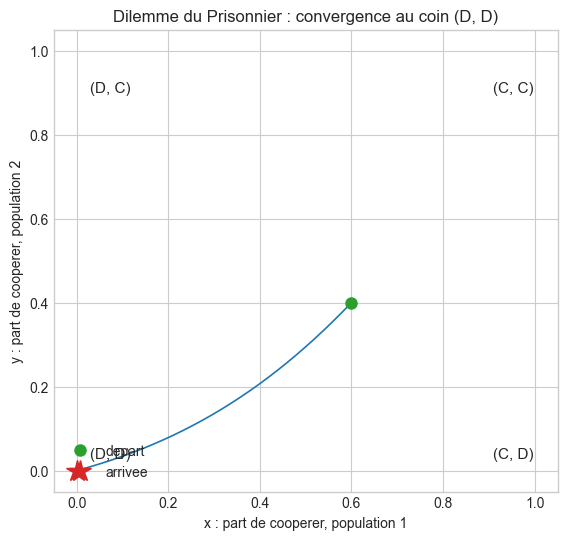

In [3]:
A_pd, B_pd = ls.prisoner_dilemma_matrices()
t_pd, tr_pd = ls.integrate_rk4(lambda z: ls.replicator_2pop_rhs(A_pd, B_pd, z),
                               ls.make_state_2pop(0.6, 0.4), 30.0, 1e-3)
regime_pd, info_pd = ls.detect_regime(t_pd, tr_pd)
x_pd, y_pd = ls.unpack_2pop(tr_pd[-1])
print("verdict       :", regime_pd)
print(f"etat final    : x = {x_pd:.2e} (part de C), y = {y_pd:.2e} (part de C)")
print(f"drift terminal: {info_pd['drift_final']:.2e}")

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(tr_pd[:, 0], tr_pd[:, 2], lw=1.2, color="tab:blue")
ax.plot([tr_pd[0, 0]], [tr_pd[0, 2]], "o", color="tab:green", ms=8, label="depart")
ax.plot([tr_pd[-1, 0]], [tr_pd[-1, 2]], "*", color="tab:red", ms=16, label="arrivee")
for cx, cy, nom in [(0, 0, "(D, D)"), (0, 1, "(D, C)"), (1, 0, "(C, D)"), (1, 1, "(C, C)")]:
    ax.annotate(nom, (cx, cy), xytext=(cx + (-0.09 if cx else 0.03),
                 cy + (-0.1 if cy else 0.03)), fontsize=11)
ax.set_xlabel("x : part de cooperer, population 1")
ax.set_ylabel("y : part de cooperer, population 2")
ax.set_title("Dilemme du Prisonnier : convergence au coin (D, D)")
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.legend(loc="lower left")
plt.show()

### Lecture du résultat

Première issue, la plus simple : la trajectoire meurt au coin $(D, D)$ — l'équilibre strict est un attracteur, le drift terminal s'effondre (5,7·10⁻¹¹ : la fenêtre terminale est immobile). Le détecteur rend `point_fixe`. Notons ce que le théorème garantit ici : peu importe le point de départ intérieur, l'ensemble $\omega$-limite sera un objet de la liste — en l'occurrence toujours ce coin.

### 2.2 Matching Pennies — l'issue orbite périodique

$(+1, -1)$ : chaque joueur veut s'aligner sur l'autre (Pile avec Pile), l'autre veut différer. Le jeu n'a aucun équilibre pur ; le mixte $(1/2, 1/2)$ est un **centre** entouré d'orbites fermées, de niveau l'invariant $x(1-x)\,y(1-y)$.

verdict : orbite_periodique
conservation relative de l'invariant x(1-x)y(1-y) : 1.94e-14
premier retour : {'t': 6.292, 'distance': 0.04979660782048693}


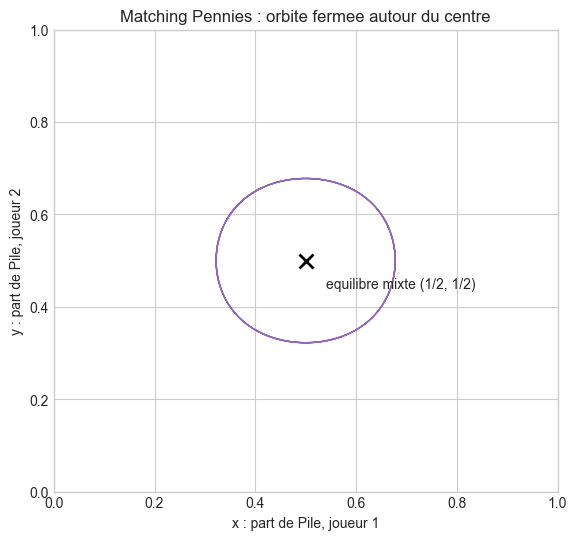

In [4]:
A_mp, B_mp = ls.matching_pennies_matrices()
rhs_mp = lambda z: ls.replicator_2pop_rhs(A_mp, B_mp, z)
t_mp, tr_mp = ls.integrate_rk4(rhs_mp, ls.make_state_2pop(0.35, 0.6), 20.0, 1e-3)
inv_mp = np.array([ls.mp_invariant(z) for z in tr_mp])
regime_mp, info_mp = ls.detect_regime(t_mp, tr_mp)
print("verdict :", regime_mp)
print(f"conservation relative de l'invariant x(1-x)y(1-y) : {np.ptp(inv_mp) / inv_mp[0]:.2e}")
print("premier retour :", info_mp["premier_retour"])

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(tr_mp[:, 0], tr_mp[:, 2], lw=1.0, color="tab:purple")
ax.plot([0.5], [0.5], "x", color="k", ms=10, mew=2)
ax.annotate("equilibre mixte (1/2, 1/2)", (0.5, 0.5), xytext=(0.54, 0.44), fontsize=10)
ax.set_xlabel("x : part de Pile, joueur 1")
ax.set_ylabel("y : part de Pile, joueur 2")
ax.set_title("Matching Pennies : orbite fermee autour du centre")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.show()

### Lecture du résultat

Deuxième issue : la trajectoire **revient** à son point de départ — le détecteur rend `orbite_periodique`, et la conservation de l'invariant à $10^{-15}$ relative est la preuve numérique que la boucle est bien fermée (chaque orbite vit entière sur une ligne de niveau de $x(1-x)\,y(1-y)$). Aucun des deux joueurs ne converge : l'apprentissage ne s'arrête jamais, il tourne. La linéarisation au centre donne une pulsation $\omega = 1$, donc une période $2\pi \approx 6{,}28$ aux petites amplitudes — vérifions ça, et voyons ce que l'amplitude en fait.

 amplitude    periode    2*pi


      0.01      6.284   6.283


      0.05      6.315   6.283


      0.15      6.583   6.283


      0.35      8.555   6.283


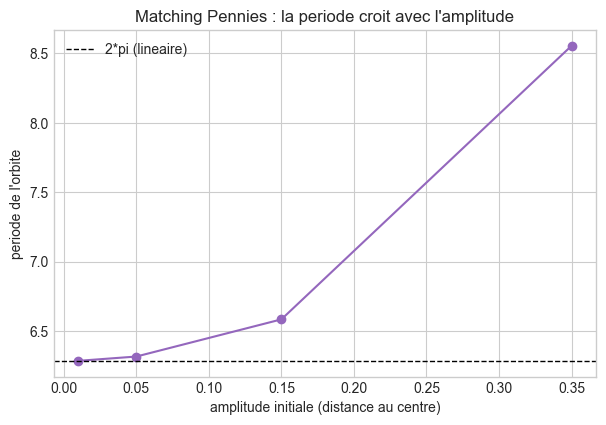

In [5]:
print(f"{'amplitude':>10} {'periode':>10} {'2*pi':>7}")
periodes = []
deltas = [0.01, 0.05, 0.15, 0.35]
for d in deltas:
    t2, tr2 = ls.integrate_rk4(rhs_mp, ls.make_state_2pop(0.5 + d, 0.5 + d), 30.0, 1e-3)
    xs = tr2[:, 0]
    seuil = xs.min() + 0.25 * d
    mins = [i for i in range(1, len(xs) - 1)
            if xs[i] < xs[i - 1] and xs[i] <= xs[i + 1] and xs[i] < seuil]
    gardes = []
    for i in mins:
        if not gardes or t2[i] - t2[gardes[-1]] > 2.0:
            gardes.append(i)
    per = t2[gardes[1]] - t2[gardes[0]]
    periodes.append(per)
    print(f"{d:>10.2f} {per:>10.3f} {2 * np.pi:>7.3f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(deltas, periodes, "o-", color="tab:purple")
ax.axhline(2 * np.pi, ls="--", color="k", lw=1, label="2*pi (lineaire)")
ax.set_xlabel("amplitude initiale (distance au centre)")
ax.set_ylabel("periode de l'orbite")
ax.set_title("Matching Pennies : la periode croit avec l'amplitude")
ax.legend()
plt.show()

### Lecture du résultat

Aux petites amplitudes, la période mesurée colle à la prédiction $2\pi$ de la linéarisation — puis elle **croît** avec l'amplitude : l'orbite est fermée mais le champ la ralentit loin du centre. C'est le comportement typique d'un système conservatif non linéaire : la linéarisation décrit le voisinage du centre, pas l'orbite entière.

### 2.3 Pierre-Feuille-Ciseaux, $w < l$ — l'issue cycle hétéroclinique

Une population, trois stratégies. La victoire rapporte $w$, la défauche coûte $-l$. Quand perdre coûte plus que gagner ne rapporte ($w < l$), le barycentre devient instable et la trajectoire, partie de l'intérieur, s'enroule vers la frontière — sans jamais s'y arrêter : elle colle à chaque coin (Pierre élimine Ciseaux, Feuille enveloppe Pierre, Ciseaux coupent Feuille) puis le quitte, de plus en plus lentement.

verdict : cycle_heteroclinique
temps de sejour par sommet dominant :
     3.7     2.0     2.5     2.9     3.8     5.4     8.8    15.5    28.9
rapport dernier / mediane des precedents : 7.7
coord minimale de la fenetre terminale  : 6.02e-41


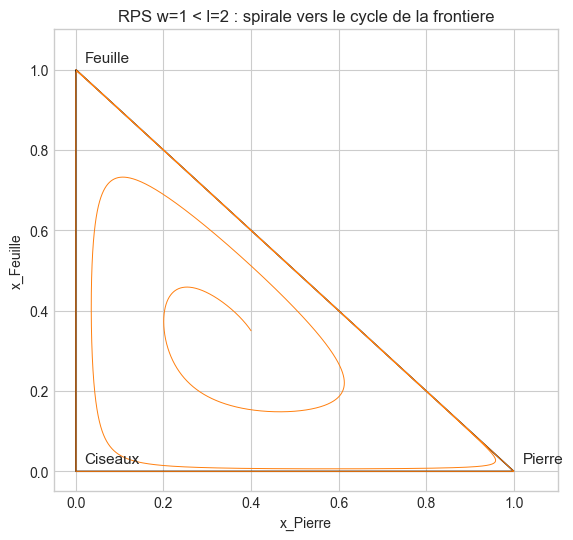

In [6]:
A_het = ls.rps_matrix(1.0, 2.0)
t_het, tr_het = ls.integrate_rk4(lambda z: ls.replicator_1pop_rhs(A_het, z),
                                 np.array([0.4, 0.35, 0.25]), 120.0, 1e-3)
regime_het, info_het = ls.detect_regime(t_het, tr_het)
sejours = info_het["temps_de_sejour"]
print("verdict :", regime_het)
print("temps de sejour par sommet dominant :")
print("  " + "  ".join(f"{g:6.1f}" for g in sejours))
print(f"rapport dernier / mediane des precedents : {sejours[-1] / float(np.median(sejours[:-1])):.1f}")
print(f"coord minimale de la fenetre terminale  : {info_het['distance_frontiere_finale']:.2e}")

fig, ax = plt.subplots(figsize=(6.5, 6))
triangle = plt.Polygon([[0, 0], [1, 0], [0, 1]], fill=False, edgecolor="k", lw=1)
ax.add_patch(triangle)
ax.plot(tr_het[:, 0], tr_het[:, 1], lw=0.7, color="tab:orange")
for px, py, nom in [(1, 0, "Pierre"), (0, 1, "Feuille"), (0, 0, "Ciseaux")]:
    ax.annotate(nom, (px, py), xytext=(px + 0.02, py + 0.02), fontsize=11)
ax.set_xlabel("x_Pierre"); ax.set_ylabel("x_Feuille")
ax.set_title("RPS w=1 < l=2 : spirale vers le cycle de la frontiere")
ax.set_xlim(-0.05, 1.1); ax.set_ylim(-0.05, 1.1)
plt.show()

### Lecture du résultat

Troisième issue : ni convergence, ni retour. La trajectoire s'approche du cycle Pierre $\to$ Feuille $\to$ Ciseaux $\to$ Pierre qui relie les trois coins de la frontière — un **cycle hétéroclinique** — et les temps de séjour par sommet s'allongent au fil du run (2,0 → 28,9 mesurés ci-dessus) : le ralentissement hétéroclinique. L'ensemble $\omega$-limite est ce cycle tout entier ; la trajectoire n'atteint jamais aucun des équilibres qu'il relie. (Un test de régression du module couvre le cas extrême : à $t_{\max} = 200$, la fenêtre terminale semble immobile alors que la trajectoire est simplement en pleine rampe près d'un coin — chaque départ de dominance constaté réfute la convergence.)

## 3. Le mur $w = l$ : une paroi dans l'espace des jeux

Le [GameTheory-3b](GameTheory-3b-Chambres-et-Murs.ipynb) parcourt l'espace des jeux comme un arrangement de **chambres** séparées par des **murs** — les égalités. La famille RPS paramétrée par $(w, l)$ traverse exactement un tel mur : la diagonale $w = l$. De part et d'autre, deux chambres de régimes ; sur le mur, le troisième type.

La linéarisation au barycentre le dit en une ligne : sur le plan tangent, les valeurs propres du champ ont pour partie réelle $(l - w)/6$ — négative si $w > l$ (barycentre attracteur, spirale rentrante), positive si $w < l$ (barycentre répulsif, $\omega$-limite rejetée vers la frontière), nulle sur le mur (centre). Vérifions la formule numériquement, puis balayons le mur.

In [7]:
def jacobien_complet(A, eps=1e-6):
    bary = np.full(3, 1.0 / 3.0)
    J = np.zeros((3, 3))
    for k in range(3):
        e = np.zeros(3); e[k] = eps
        J[:, k] = (ls.replicator_1pop_rhs(A, bary + e)
                   - ls.replicator_1pop_rhs(A, bary - e)) / (2 * eps)
    return J

# Le jacobien 3x3 porte une troisieme valeur propre (direction sortante du
# simplexe, de partie reelle (l-w)/3) : la paire du plan tangent — celle que
# la formule decrit — est celle de partie imaginaire non nulle.
print(f"{'w':>4} {'l':>4} {'vp tangente':>20} {'(l-w)/6':>9}")
for w, l in [(2.0, 1.0), (1.5, 1.5), (1.0, 2.0)]:
    ev = np.linalg.eigvals(jacobien_complet(ls.rps_matrix(w, l)))
    tang = ev[np.argmax(np.abs(ev.imag))]
    print(f"{w:>4.1f} {l:>4.1f} {tang.real:>+12.4f}{tang.imag:+.4f}i {(l - w) / 6.0:>+9.4f}")
    assert abs(tang.real - (l - w) / 6.0) < 5e-3

   w    l          vp tangente   (l-w)/6
 2.0  1.0      -0.1667+0.8660i   -0.1667
 1.5  1.5      -0.0000+0.8660i   +0.0000
 1.0  2.0      +0.1667+0.8660i   +0.1667


   w    l   (l-w)/6  regime mesure       


 2.5  0.5    -0.333  point_fixe          


 2.0  1.0    -0.167  point_fixe          


 1.5  1.5    +0.000  orbite_periodique   


 1.0  2.0    +0.167  cycle_heteroclinique


 0.5  2.5    +0.333  cycle_heteroclinique


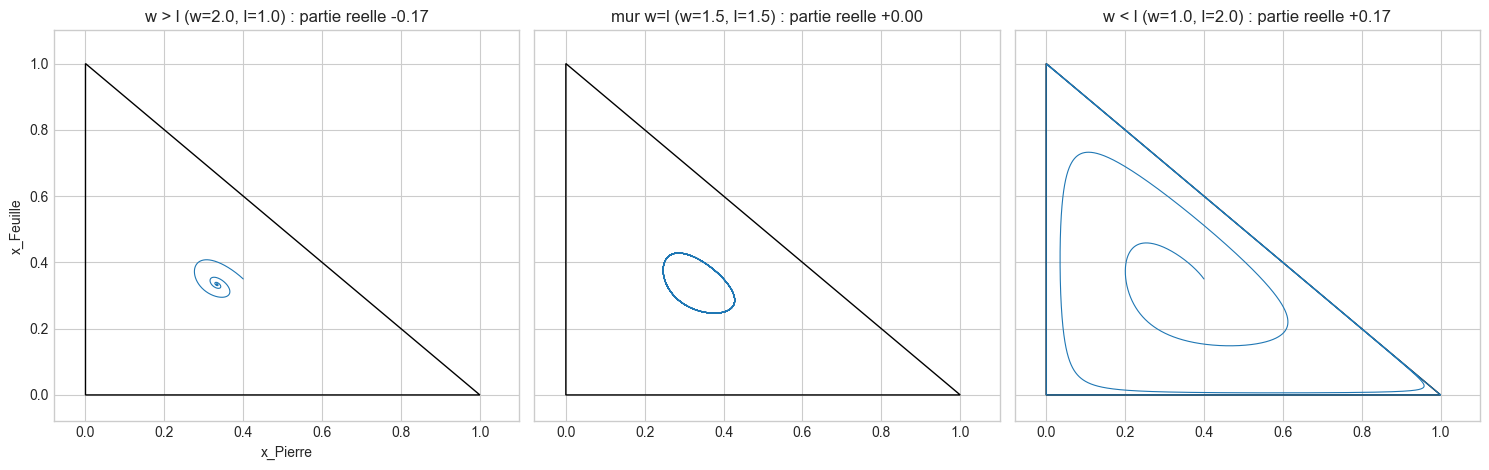

In [8]:
print(f"{'w':>4} {'l':>4} {'(l-w)/6':>9}  {'regime mesure':<20}")
configs = [(2.5, 0.5), (2.0, 1.0), (1.5, 1.5), (1.0, 2.0), (0.5, 2.5)]
for w, l in configs:
    A = ls.rps_matrix(w, l)
    t3, tr3 = ls.integrate_rk4(lambda z: ls.replicator_1pop_rhs(A, z),
                               np.array([0.4, 0.35, 0.25]), 120.0, 1e-3)
    regime3, _ = ls.detect_regime(t3, tr3)
    print(f"{w:>4.1f} {l:>4.1f} {(l - w) / 6.0:>+9.3f}  {regime3:<20}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)
for ax, (w, l) in zip(axes, [(2.0, 1.0), (1.5, 1.5), (1.0, 2.0)]):
    A = ls.rps_matrix(w, l)
    t3, tr3 = ls.integrate_rk4(lambda z: ls.replicator_1pop_rhs(A, z),
                               np.array([0.4, 0.35, 0.25]), 80.0, 1e-3)
    ax.add_patch(plt.Polygon([[0, 0], [1, 0], [0, 1]], fill=False,
                             edgecolor="k", lw=1))
    ax.plot(tr3[:, 0], tr3[:, 1], lw=0.8)
    nom_mur = "mur w=l" if abs(w - l) < 1e-9 else ("w < l" if w < l else "w > l")
    ax.set_title(f"{nom_mur} (w={w}, l={l}) : partie reelle {(l - w) / 6.0:+.2f}")
    ax.set_xlim(-0.08, 1.1); ax.set_ylim(-0.08, 1.1)
axes[0].set_xlabel("x_Pierre"); axes[0].set_ylabel("x_Feuille")
plt.tight_layout()
plt.show()

### Lecture du résultat

Le signe de $(l-w)/6$ **prédit** le régime mesuré sur toute la ligne $w + l = 3$ : négatif à droite du mur — spirale rentrante vers le barycentre, `point_fixe` ; positif à gauche — rejet vers le cycle de la frontière, `cycle_heteroclinique` ; nul **sur** le mur — orbites neutres fermées, `orbite_periodique`. Les trois portraits disent la même chose géométriquement : en traversant le mur $w = l$, l'$\omega$-limite saute du barycentre aux orbites fermées, puis au cycle de la frontière. C'est exactement le vocabulaire du 3b : une paroi de codimension 1 dans l'espace des familles de jeux, deux chambres de régimes de part et d'autre — et le régime du mur lui-même.

## 4. Exercices

### Exercice 1 — Chasse au Cerf : un jeu, deux bassins

Le module fournit `ls.stag_hunt_matrices()` : $A = \begin{pmatrix} 4 & 1 \\ 3 & 2 \end{pmatrix}$, $B = A^\top$ (la transposée n'est **pas** optionnelle : $A$ n'est pas symétrique). Deux conditions initiales vous sont données. Pour chacune : intégrer, classer le régime, identifier l'attracteur atteint — puis dire ce qui sépare les deux issues.

In [9]:
# Exercice 1 -- Chasse au Cerf : identifier le regime et les bassins
A_cerf, B_cerf = ls.stag_hunt_matrices()
depart_haut = (0.62, 0.62)   # x + y > 1
depart_bas = (0.30, 0.30)    # x + y < 1
# Etape 1 : integrer les deux trajectoires (t_max=60, dt=1e-3).
# Etape 2 : pour chacune, appliquer detect_regime et lire l'etat final.
# Etape 3 : formuler ce qui separe les deux bassins (indice : une droite du
#           carre passe par la selle interieure ; laquelle ?).
verdict_exo1 = None  # TODO etudiant : (regime_haut, regime_bas, separateur)
print("Exercice a completer")

Exercice a completer


### Exercice 2 — Personne ne quitte son ensemble limite

Le théorème dit que la trajectoire **reste** sur son ensemble limite. Vérifiez-le par la mesure pour Matching Pennies depuis une autre condition initiale $(0.2, 0.75)$ : l'invariant $x(1-x)\,y(1-y)$ doit rester constant le long de la trajectoire — à quelle précision relative ? Et pour RPS $w < l$, la trajectoire intérieure s'approche de la frontière sans jamais la toucher : quelle est la coordonnée minimale atteinte sur tout le run ?

In [10]:
# Exercice 2 -- mesurer la conservation des ensembles limites
# Etape 1 : MP depuis (0.2, 0.75) -- t_max=20, dt=1e-3 : max_t |inv(t) - inv(0)|
#           relatif a inv(0).
# Etape 2 : RPS w=1, l=2 depuis (0.4, 0.35, 0.25) -- t_max=120 : min de toutes
#           les coordonnees de la trajectoire (interieur strict conserve ?).
# Indice : ls.mp_invariant(z) donne l'invariant ; np.min(traj) le minimum.
conservation_exo2 = None  # TODO etudiant : (ecart_relatif_mp, coord_min_rps)
print("Exercice a completer")

Exercice a completer


### Exercice 3 — Trouver le mur à la bisection

La section 3 a montré le mur $w = l$ sur la ligne $w + l = 3$. On va le trouver **sans** la formule : fixez $l = 2$ et balayez $w$ — pour chaque $w$, intégrez (t_max=120, dt=1e-3) et classez. Par bisection sur le verdict (`point_fixe` vs autre chose), localisez le mur à $\pm 0{,}01$ près, puis comparez à la prédiction $w = l = 2$.

In [11]:
# Exercice 3 -- bisection sur w pour localiser le mur (l = 2 fixe)
# Etape 1 : deux bornes de part et d'autre du mur (verifiez leurs verdicts).
# Etape 2 : bisection ~7 iterations pour une precision de 0.01 sur w.
# Etape 3 : comparer la valeur trouvee a l et commenter l'ecart.
mur_exo3 = None  # TODO etudiant : w trouve par bisection
print("Exercice a completer")

Exercice a completer


## Conclusion

Trois jeux, trois issues, et une liste **fermée** : point fixe, orbite périodique, cycle hétéroclinique. C'est le privilège de la dimension 2, et il a un prix symétrique : **le théorème tombe dès qu'on quitte le plan**. Deux populations sur trois stratégies (dimension 4), une population sur quatre stratégies (dimension 3) — l'alternative n'y est plus exhaustive, et des comportements chaotiques sont documentés dans ces cadres (Hofbauer-Sigmund pour le replicateur à assez de stratégies ; Sato-Akiyama-Crutchfield 2005 pour l'apprentissage avec mémoire en jeu à deux). Ce notebook ne généralise pas : l'échec du théorème au-delà du plan **est** la leçon — la classification que vous venez d'exécuter est un théorème de géométrie, pas une propriété de l'apprentissage en général.

**Source** : Czechowski & Piliouras (2021), *Poincaré-Bendixson Limit Sets in Multi-Agent Learning* — bibliothèque locale : `G:/Mon Drive/MyIA/IA/Bibliographie IA/GameTheory/2021 - Czechowski Piliouras - Poincare-Bendixson Limit Sets in Multi-Agent Learning.pdf` (citée, jamais copiée dans le dépôt).

*Voir #12570 (grain). Companion : [`limit_sets.py`](limit_sets.py) + [`tests/test_limit_sets.py`](tests/test_limit_sets.py) (16 tests).*